# Fine-tune ConvNeXt v2 บนชุดข้อมูลภาพแบบกำหนดเอง

สรุป: โน้ตบุ๊กนี้แสดงการเตรียมข้อมูล, สร้าง pipeline preprocessing, ปรับแต่งโมเดล `ConvNeXt v2`, ประเมินผลด้วย metrics และทดสอบ inference ด้วยภาพตัวอย่าง

ขั้นตอนหลัก:
1. โหลดและสำรวจชุดข้อมูล
2. สร้าง preprocessing pipeline และ DataLoader
3. โหลดโมเดล ConvNeXt v2 พร้อมจัดการ label mapping
4. ฝึกโมเดลและติดตาม loss / accuracy
5. ประเมินผลและสร้าง confusion matrix
6. ตัวอย่างการใช้งาน inference บนภาพใหม่


## 1. โหลดและสำรวจข้อมูล

โหลดชุดข้อมูลจาก `imagefolder` และสำรวจ metadata เพื่อเตรียมความพร้อมก่อน preprocessing


In [2]:
from datasets import load_dataset

In [3]:
dataset = load_dataset("imagefolder", data_dir="/kaggle/input/scscsc/final_dataset_split")

Resolving data files:   0%|          | 0/1800 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/514 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/260 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [4]:
dataset["train"].features

{'image': Image(mode=None, decode=True, id=None),
 'label': ClassLabel(names=['0', '1'], id=None)}

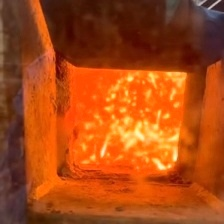

In [5]:
example = dataset["train"][80]
example["image"]

In [6]:
labels = dataset["train"].features["label"].names
print(labels)

['0', '1']


In [7]:
id2label = {k:v for k,v in enumerate(labels)}
label2id = {v:k for k,v in enumerate(labels)}
print(id2label)

{0: '0', 1: '1'}


## 2. สร้าง pipeline preprocessing และ DataLoader

กำหนดการแปลงภาพเข้าโมเดลโดยใช้ `torchvision.transforms` และสร้าง `DataLoader` สำหรับการฝึกสอน


In [8]:
from transformers import AutoImageProcessor

2025-10-02 12:31:54.547922: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759408314.735677      60 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759408314.794517      60 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [9]:
image_processor = AutoImageProcessor.from_pretrained("facebook/convnextv2-tiny-1k-224")

preprocessor_config.json:   0%|          | 0.00/352 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [10]:
from torchvision.transforms import (
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    ToTensor,
)

normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)

transform = Compose(
    [
     RandomResizedCrop(image_processor.size["shortest_edge"]),
     RandomHorizontalFlip(),
     ToTensor(),
     normalize
    ]
)

def train_transforms(examples):
  examples["pixel_values"] = [transform(image.convert("RGB")) for image in examples["image"]]

  return examples

In [11]:
processed_dataset = dataset.with_transform(train_transforms)

In [12]:
processed_dataset["train"][0].keys()

dict_keys(['image', 'label', 'pixel_values'])

In [13]:
import torch
from torch.utils.data import DataLoader

def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

dataloader = DataLoader(processed_dataset["train"], collate_fn=collate_fn, batch_size=4, shuffle=True)

In [14]:
batch = next(iter(dataloader))
for k,v in batch.items():
  print(k,v.shape)

pixel_values torch.Size([4, 3, 224, 224])
labels torch.Size([4])


## 3. โหลดโมเดลและจัดการ label mapping

เตรียม `id2label` และ `label2id` จาก dataset แล้วโหลดโมเดล ConvNeXt v2 สำหรับการ fine-tuning


In [60]:
from transformers import AutoImageProcessor, AutoModelForImageClassification


id2label = {0: "0", 1: "1"}
label2id = {"0": 0, "1": 1}

model = AutoModelForImageClassification.from_pretrained("facebook/convnextv2-tiny-1k-224",
                                                        id2label=id2label,
                                                        label2id=label2id,
                                                        num_labels= 2,
                                                        ignore_mismatched_sizes=True)

Some weights of ConvNextV2ForImageClassification were not initialized from the model checkpoint at facebook/convnextv2-tiny-1k-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 4. ฝึกโมเดล ConvNeXt v2

ดำเนินการ training loop พร้อม optimizer `AdamW`, ย้ายข้อมูลและโมเดลไปยัง GPU ถ้ามี และติดตาม loss กับ accuracy ในแต่ละขั้นตอน


In [61]:
from tqdm.notebook import tqdm
import torch

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

# move model to GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

model.train()
for epoch in range(2):
  print("Epoch:", epoch)
  correct = 0
  total = 0
  for idx, batch in enumerate(dataloader):
    # move batch to GPU
    batch = {k:v.to(device) for k,v in batch.items()}

    optimizer.zero_grad()

    # forward pass
    outputs = model(pixel_values=batch["pixel_values"],
                    labels=batch["labels"])

    loss, logits = outputs.loss, outputs.logits
    loss.backward()
    optimizer.step()

    # metrics
    total += batch["labels"].shape[0]
    predicted = logits.argmax(-1)
    correct += (predicted == batch["labels"]).sum().item()

    accuracy = correct/total

    if idx % 100 == 0:
      print(f"Loss after {idx} steps:", loss.item())
      print(f"Accuracy after {idx} steps:", accuracy)

Epoch: 0
Loss after 0 steps: 0.6085687875747681
Accuracy after 0 steps: 1.0
Loss after 100 steps: 0.011721782386302948
Accuracy after 100 steps: 0.9653465346534653
Loss after 200 steps: 0.33557987213134766
Accuracy after 200 steps: 0.9763681592039801
Loss after 300 steps: 0.004508529789745808
Accuracy after 300 steps: 0.978405315614618
Loss after 400 steps: 0.003147773677483201
Accuracy after 400 steps: 0.979426433915212
Epoch: 1
Loss after 0 steps: 0.0015370722394436598
Accuracy after 0 steps: 1.0
Loss after 100 steps: 0.00035323662450537086
Accuracy after 100 steps: 1.0
Loss after 200 steps: 0.0004331690142862499
Accuracy after 200 steps: 0.9950248756218906
Loss after 300 steps: 0.0005600813310593367
Accuracy after 300 steps: 0.9950166112956811
Loss after 400 steps: 0.0008954029181040823
Accuracy after 400 steps: 0.9950124688279302


In [57]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from PIL import Image
from tqdm import tqdm

In [79]:
model.save_pretrained("/kaggle/working/")
feature_extractor.save_pretrained("/kaggle/working/")


['/kaggle/working/preprocessor_config.json']

In [63]:
from transformers import pipeline
import torch

pipe = pipeline(
    task="image-classification", 
    model="dreamypancake/fine_tune_Car_ConvNeXTv2",
    device="cuda" if torch.cuda.is_available() else "cpu",
)



Device set to use cuda


## 5. ประเมินผลด้วยชุดทดสอบ

โหลดชุดทดสอบ, สร้าง DataLoader, ประมวลผลโมเดลแบบ `eval` และแสดง classification report


In [68]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch
from transformers import AutoImageProcessor

# --- 1. Dataset class สำหรับ PyTorch ---
class CustomImageDataset(Dataset):
    def __init__(self, images, labels, feature_extractor, label2id):
        self.images = images
        self.labels = labels
        self.feature_extractor = feature_extractor
        self.label2id = label2id

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        # แปลง label เป็น int
        label_id = self.label2id[label]

        # preprocess image
        encoding = self.feature_extractor(image, return_tensors="pt")
        pixel_values = encoding['pixel_values'].squeeze()  # remove batch dim

        return {"pixel_values": pixel_values, "labels": torch.tensor(label_id, dtype=torch.long)}


# --- 2. ฟังก์ชันโหลด test dataset ---
def load_test_dataset(dataset_path):
    images = []
    labels = []
    class_names = []
        
    for class_name in sorted(os.listdir(dataset_path)):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            class_names.append(class_name)
            for img_file in os.listdir(class_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_path, img_file)
                    try:
                        img = Image.open(img_path).convert('RGB')
                        images.append(img)
                        labels.append(class_name)
                    except Exception as e:
                        print(f"Error loading {img_path}: {e}")
        
    return images, labels, class_names


# --- 3. เตรียม feature extractor และ label mapping ---
feature_extractor = AutoImageProcessor.from_pretrained("convnext_finetuned")  # path ของโมเดลที่คุณ fine-tune
label2id = {"0": 0, "1": 1}

# --- 4. โหลด test dataset ---
dataset_path = "/kaggle/input/scscsc/final_dataset_split/test"  # ปรับ path ให้ตรงกับคุณ
images, labels, class_names = load_test_dataset(dataset_path)

# --- 5. สร้าง PyTorch Dataset และ DataLoader ---
test_dataset = CustomImageDataset(images, labels, feature_extractor, label2id)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [69]:
model.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for batch in test_loader:
        batch = {k:v.to(device) for k,v in batch.items()}
        outputs = model(pixel_values=batch["pixel_values"])
        preds = outputs.logits.argmax(-1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(batch["labels"].cpu().numpy())

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, labels=[0,1], target_names=["0","1"]))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00       136
           1       1.00      0.99      1.00       124

    accuracy                           1.00       260
   macro avg       1.00      1.00      1.00       260
weighted avg       1.00      1.00      1.00       260



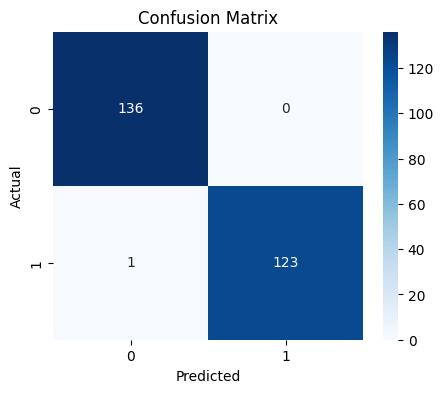

In [70]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# สร้าง confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0,1])

# แสดงผลด้วย heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["0","1"], yticklabels=["0","1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [80]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
import torch
from PIL import Image

# path ของโมเดลที่คุณ save หลัง fine-tune
model_path = "/kaggle/working/convnext_2class"

# โหลด feature extractor และโมเดล
feature_extractor = AutoImageProcessor.from_pretrained(model_path)
model = AutoModelForImageClassification.from_pretrained(model_path)

# ส่งโมเดลไป GPU ถ้ามี
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()


ConvNextV2ForImageClassification(
  (convnextv2): ConvNextV2Model(
    (embeddings): ConvNextV2Embeddings(
      (patch_embeddings): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (layernorm): ConvNextV2LayerNorm()
    )
    (encoder): ConvNextV2Encoder(
      (stages): ModuleList(
        (0): ConvNextV2Stage(
          (downsampling_layer): Identity()
          (layers): Sequential(
            (0): ConvNextV2Layer(
              (dwconv): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
              (layernorm): ConvNextV2LayerNorm()
              (pwconv1): Linear(in_features=96, out_features=384, bias=True)
              (act): GELUActivation()
              (grn): ConvNextV2GRN()
              (pwconv2): Linear(in_features=384, out_features=96, bias=True)
              (drop_path): Identity()
            )
            (1): ConvNextV2Layer(
              (dwconv): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
    

## 6. ตัวอย่างการใช้งาน Inference

โหลดโมเดลที่บันทึกไว้, เตรียมภาพตัวอย่าง และทำนายคลาสแบบเรียลไทม์


In [84]:
# ตัวอย่างโหลดรูปเดียว
img_path = "/kaggle/input/scscsc/final_dataset_split/test/1/ดี_frame_00015_aug0.jpg"
image = Image.open(img_path).convert("RGB")

# preprocess
inputs = feature_extractor(image, return_tensors="pt").to(device)


In [85]:
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class_idx = logits.argmax(-1).item()  # index ของ class
    predicted_label = model.config.id2label[predicted_class_idx]

print("Predicted class:", predicted_label)


Predicted class: 1
